# TD 4 : Prévisions de séries temporelles 

Dans le TD précédent, nous avons vu comment choisir entre une modélisation additive et multiplicative d'une série temporelle. Dans ce TD, nous allons faire des prévisions de la série temporelle.

Pour cela nous allons :
1) Importer les libraires utiles et mettre en forme la base de données
2) Faire un test de "non-stationnarité" sur la série temporelle de base
3) Scinder l'échantillon initial en deux, et, en s'appuyant sur le sous-échantillon d'apprentissage, faire des prévision sur le sous-échantillon test.


## Partie 1. Échauffement : Importation des librairies, mise en forme et visualisation des données

Pour commencer, importons les librairies dont nous aurons besoin :

In [232]:
# DataFrame
import pandas as pd
# numeric calculations
import numpy as np
# datetime
from datetime import datetime

In [233]:
# visualisation
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
from matplotlib.pyplot import figure
#figure(num=None, figsize=(16, 12), dpi=80, facecolor='w', edgecolor='k')

In [234]:
import statsmodels.api as sm
# Holt-Winters Model
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
import statsmodels.tsa.api as smt
from statsmodels.tsa.stattools import adfuller # Augmented Dickey-Fuller (ADF) test
from statsmodels.tsa.arima_model import ARIMA
import statsmodels.formula.api as smf

In [235]:
import sys

In [236]:
import itertools

In [237]:
import warnings
warnings.filterwarnings("ignore")

Reprenons le jeu de données `AirPassengers` qui représente le nombre de passagers aériens voyageant en international entre 1949 et 1960, donnés en milles de personnes. 

Importer le fichier `AirPassengers.csv` dans le même dossier que votre notebook python et exécuter les commandes suivantes :

In [238]:
airpax_data = pd.read_csv("AirPassengers.csv")
airpax_data.head()

,t,Airpass
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


Puis, comme dans le précedent TD, transformer ces données en une série temporelle. Cette fois-ci on va le faier en modifiant directement le DataFrame.

In [239]:
# Parse strings to datetime type
# convert from String to Datetime
airpax_data['t'] = pd.to_datetime(airpax_data['t'], infer_datetime_format=True)
airpax_data = airpax_data.set_index(['t']) # set the date as index
airpax_data

,Airpass
t,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


Visualiser cette série.

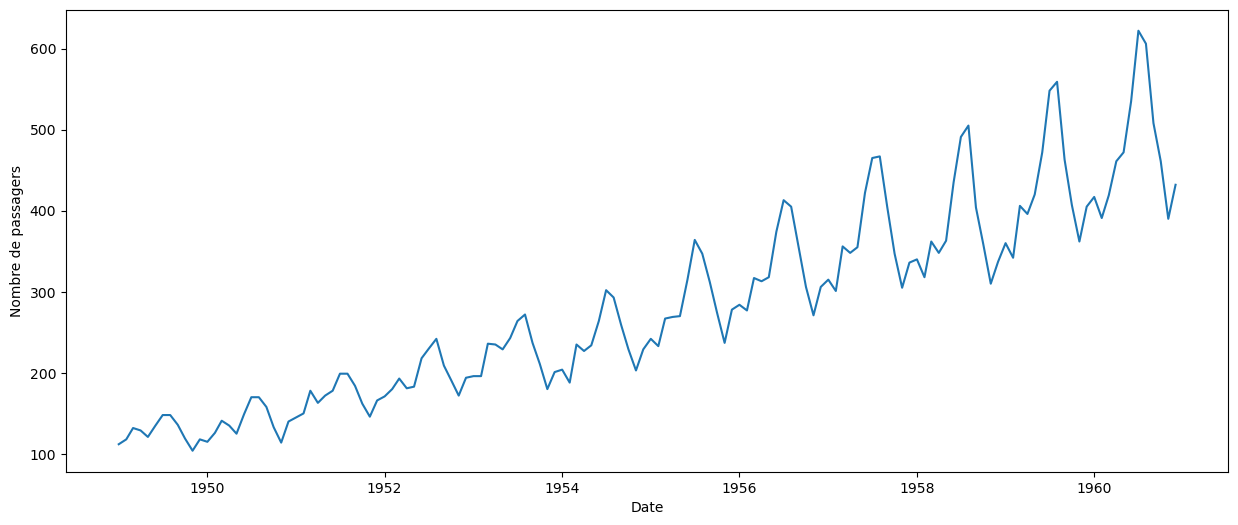

In [240]:
plt.xlabel('Date')
plt.ylabel('Nombre de passagers')
plt.plot(airpax_data)

Notre objectif principal est de pouvoir prédire les futures valeurs de la série temporelle, autrement dit de faire des **prévisions** (en: *forecasting*).

## Partie 2. Test de "non stationnarité" sur la série

<div class="alert alert-block alert-info">
    Soit un <b>processus temporel</b> défini par une suite de variables aléatoires indexées par le temps $(X_t)$, $t \in R$. On dit qu'une série temporelle est <b>stationnaire</b> lorsque les espérances et (co)variances des $X_t$ sont constantes pour tout t.
</div>

La notion de stationnarité est importante dans le contexte de prévision pour les raisons suivantes :

1. *Les propriétés statistiques restent constantes* : une série stationnaire conserve une moyenne, une variance et une structure d'autocorrélation constantes dans le temps, ce qui rend les modèles plus prévisibles.
2. *Fiabilité du modèle* : la plupart des modèles de séries temporelles (comme ARIMA) supposent la stationnarité. Lorsque cette hypothèse est violée, les prévisions deviennent peu fiables.
3. *Relations fallacieuses* : les données non stationnaires peuvent montrer des relations apparemment significatives qui n'existent pas réellement.
4. *Retour à la moyenne* : les séries stationnaires ont tendance à revenir à leur moyenne, fournissant ainsi une base de référence pour les prévisions.
5. *Généralisabilité* : les patterns appris à partir de données stationnaires restent valables pour les prévisions futures.

Dans certains cas il est possible de faire une **inspection graphique** afin de déterminer si la série temporelle est stationnaire ou non-stationnaire. 

Reprenons notre cas de `AirPassangers` :

* *Présence d'une tendance croissante / décroissante* : Nous remarquons la présence de la tendance croissante, ce qui indique la non-stationnarité
* *Variance qui change dans le temps* : Nous remarquons comment les fluctuations s'accentuent au fil du temps (forme d'entonnoir) ce qui indique également la non-stationnarité
* *Patterns saisonniers* : Nous constatons la présence de la saissonnalité avec les pics et creux réguliers au cours de chaque année

Suite à cette analyse visuelle, nous pouvons dire que la série étudiée est plutôt non-stationnaire.

Nous pouvons également étudier les **statistiques mobiles** (ou glissantes), notamment la moyenne et écart-type. Et nous pouvons les visualiser.

In [241]:
def plot_rolling_stats(timeseries):    
    # Determing rolling statistics
    rolmean = timeseries.rolling(window=12).mean() # rolling mean (moving average) with a window size 12 (months)
    rolstd = timeseries.rolling(window=12).std() # rolling standard deviation

    # Plot rolling statistics:
    orig = plt.plot(timeseries, color="blue", label="Original")
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

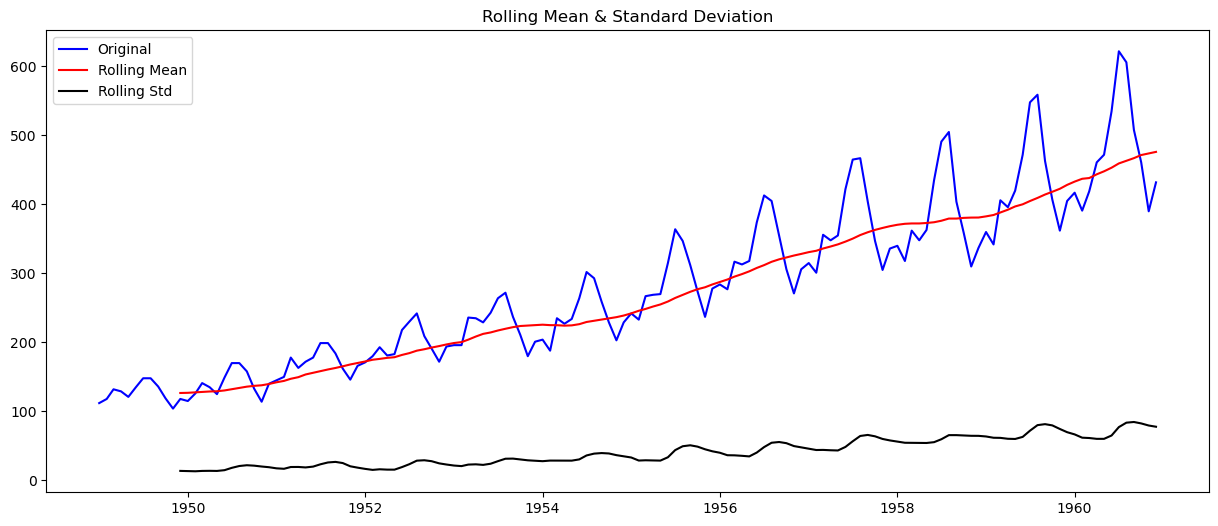

In [242]:
# etude des stats mobiles
plot_rolling_stats(airpax_data)

Les indicateurs suivants peuvent témoigner de la non-stationnarité d'une série temporelle :

* *Changement de moyenne* : une moyenne mobile non horizontale indique une tendance
* *Changement de variance* : une augmentation de l'écart-type mobile indique une hétéroscédasticité (i.e. la variabilité (variance) d'une variable se diffère selon les différentes valeurs d'une autre variable qui la prédit)

Dans notre cas, on constate donc les changement en moyenne et variance. Donc, la série est plutôt non-stationnaire.

Nous pouvons aussi faire une **analyse de la distribution** :

In [243]:
def distribution_analysis(timeseries, title='Distribution of Passenger Counts') : 
    # Plot histogram of the series
    plt.figure(figsize=(10, 6))
    plt.hist(timeseries, bins=30)
    plt.title(title)
    plt.grid(True)
    plt.show()

    # First half vs second half distributions
    mid_point = len(timeseries) // 2
    plt.figure(figsize=(12, 6))
    plt.hist(timeseries.iloc[:mid_point].values, alpha=0.5, label='First Half')
    plt.hist(timeseries.iloc[mid_point:].values, alpha=0.5, label='Second Half')
    plt.legend(loc='best')
    plt.title('Distribution: First Half vs Second Half of Time Series')
    plt.grid(True)
    plt.show()

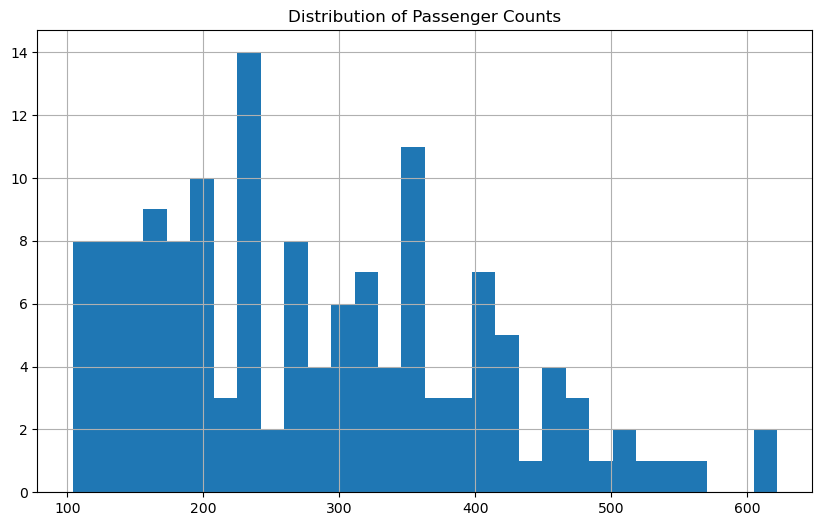

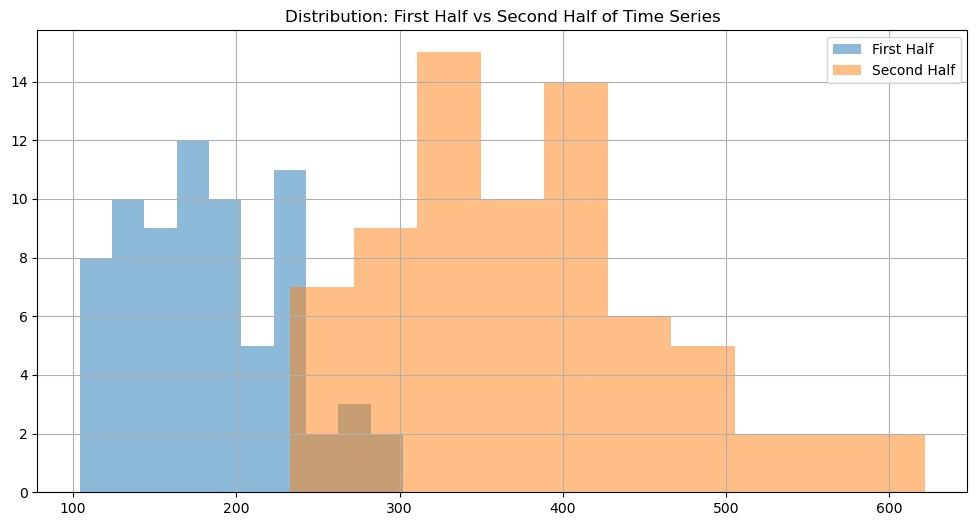

In [244]:
distribution_analysis(airpax_data)

Ici, on fait le découpage en deux sous-enseble en fonction de temps. Nous remarquons le shift dans la distribution ce qui indique la non-stationnarité.

> Est-ce qu'il y a des méthodes plus fiables qui permettent de définir si une série temporelle est stationnaire ou non-stationnaire ?

Voici une fonction introduisant un test de "non-stationnarité" : le **test de Dickey-Fuller augmenté** (son fonctionnement n'est pas au programme). On utilise l'implémentation [statsmodels.tsa.stattools.adfuller](https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html) importé au début du notebook.

In [245]:
def test_stationarity(timeseries):
    
    plot_rolling_stats(timeseries)
    
    # Perform Dickey-Fuller test:
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    # decision
    decision = 'Non-Stationary'
    comment = "Weak evidence against null hypothesis. Fail to reject the null hypothesis"
    if dftest[1] < 0.05:
        decision = 'Stationary'
        comment = "Strong evidence against the null hypothesis. Reject the null hypothesis"
    dfoutput['Decision'] = decision
    dfoutput['Comment'] = comment
    print (dfoutput)


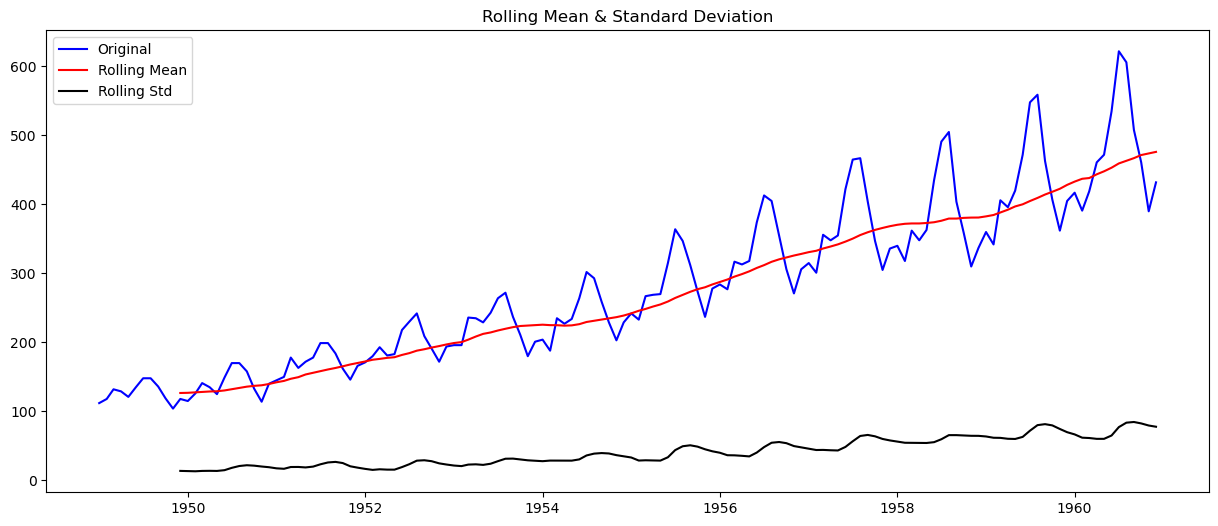

Results of Dickey-Fuller Test:
Test Statistic                                                          0.815369
p-value                                                                  0.99188
#Lags Used                                                                  13.0
Number of Observations Used                                                130.0
Critical Value (1%)                                                    -3.481682
Critical Value (5%)                                                    -2.884042
Critical Value (10%)                                                    -2.57877
Decision                                                          Non-Stationary
Comment                        Weak evidence against null hypothesis. Fail to...
dtype: object


In [246]:
# test stationarité
test_stationarity(airpax_data)

##### Interlude par les tests statistiques

**Qu'est-ce qu'un test statistique paramétrique ?**

Le but d'un test statistique est de vérifier si une hypothèse est valide ou non. Par exemple, dans l'industrie pharmaceutique nous voulons déterminer si le médicament développé est efficace ou non contre la maladie étudiée. Une fois le problème posé et l'hypothèse qui nous intéresse formulée, nous voulons étudions sa vraisemblance. Pour ce faire, nous nous intéressons à la notion de test statistique.

<div class="alert alert-block alert-info">
    Un <b>test statistique</b> est une procédure qui permet de décider si à partir des observations obtenues nous devons accepter ou rejeter l'hypothèse concernée.
</div>

Cependant, en raison de la variabilité des mesures (de l'aléatoire se cachant derrière les données obtenues), un tel test ne peut pas être catégorique : il faut donc accepter de se tromper dans la conclusion, **mais** en sachant avec quelle probabilité nous risquons de nous tromper.

**Que signifie &laquo; se tromper &raquo; et dans quelle mesure l'&laquo; accepter&raquo; ?**

Un exemple pour illustrer cette notion d'erreur de conclusion. Le maire d'une ville décide d'étudier la concentration de plomb dans une vieille école. Il effectue plusieurs mesures et obtient un indicateur de $1\mu g.m^{-3}$ (par exemple la moyenne), sachant que la norme européenne (2006) à ne pas dépasser est de $0.9\mu g.m^{-3}$. Doit-il suspendre la venue des enfants dans cette école ? L'hypothèse que veut tester le maire est "la norme est dépassée", mais il a deux façons de se tromper dans sa conclusion :
- s'il conclue que la norme est dépassée, alors qu'en réalité ce n'est pas le cas, mais que l'écart dans les observations est uniquement dû à l'aléatoire des mesures, alors l'école sera fermée sans justification ; et
- s'il conclue que la norme n'est pas dépassée, alors qu'en réalité c'est le cas, alors il y a un risque de santé publique pour les enfants et toutes les personnes travaillant dans cette école.

Nous notons généralement $(\mathcal H_0)$ l'hypothèse que nous souhaitons tester, et $(\mathcal H_1)$ l'hypothèse alternative. En fait, lorsque nous testons une hypothèse $(\mathcal H_0)$, nous testons en réalité si cette hypothèse est plus vraisemblable qu'une hypothèse alternative $(\mathcal H_1)$. 
En général, les hypothèses $(\mathcal H_0)$ et $(\mathcal H_1)$ sont complémentaires. Au vu de l'exemple ci-dessus, nous distinguons deux types de risque :
- le **risque de rejeter $(\mathcal H_0)$ à tort** : il s'agit du *risque de 1ère espèce* ; et
- le *risque de ne pas rejeter $(\mathcal H_0)$ à tort* : il s'agit du *risque de 2ème espèce*.

Idéalement, nous voudrions minimiser ces deux risques simultanément dans notre procédure de test. Mais ceci n'est pas faisable et par convention, nous décidons de contrôler le risque de 1ère espèce.

**Seuil d'un test**

<div class="alert alert-block alert-info">
    Un test de <b>seuil $\alpha$</b> est un test dont le risque de 1ère espèce vaut $\alpha$. Autrement dit, <i>la probabilité de conclure $(\mathcal H_0)$ est faux lorsque $(\mathcal H_0)$ est vérifiée vaut $\alpha$</i>.
</div>

Le choix des hypothèses se fait alors à partir de la formulation du risque qui nous intéresse. La personne qui réalise le test veut minimiser le risque de 1ère espèce. Dans l'exemple ci-dessus, le maire (que nous supposons honnête) veut minimiser le risque d'affirmer que la norme de concentration de plomb est respectée à tord, en raison du risque pour les enfants et le personnel de l'école. Son hypothèse $(\mathcal H_0)$ est donc "la norme est dépassée". Un expert mandaté par un tiers souhaitant laisser l'école ouverte choisira au contraire comme hypothèse $(\mathcal H_0)$ "la norme est respectée".

**$p$-valeur**

> [TL;DR]
La p-valeur répond à une question spécifique : « Si rien d'inhabituel ne se produit (hypothèse nulle vraie), quelle est la probabilité de voir des résultats aussi extrêmes ou plus extrêmes que ceux que nous avons observés ? »
>
> Pensez-y de cette façon :
>> - C'est comme mesurer à quel point vous devriez être surpris par votre preuve (valeur de la statistique de test calculée à partir des observations) .
>> - Une très petite p-valeur  (généralement < 0,05) signifie « Cette preuve serait assez rare si rien d'inhabituel ne se produisait ».
>> - Il ne s'agit PAS de la probabilité que votre hypothèse soit correcte ou incorrecte.
>
> **Comment comprendre et utiliser les p-valeurs**
> Interprétation pratique pour le scénario "*H0 : "Ce médicament n'a pas d'effet*":
>>- p = 0,01 : « S'il n'y avait vraiment aucun effet, nous ne verrions des résultats aussi extrêmes qu'environ 1 % du temps par pur hasard. »
>>- p = 0,30 : « S'il n'y avait vraiment aucun effet, nous verrions des résultats aussi extrêmes ou plus fréquemment (30 % du temps) par pur hasard. »
> 
> Ainsi, lorsque nous disons : « *S'il n'y avait vraiment aucun effet, nous ne verrions des preuves aussi extrêmes qu'environ 1 % du temps* », nous voulons dire : « *Des statistiques de test de cette ampleur ou plus ne se produiraient que dans environ 1 % des expériences si l'hypothèse nulle était vraie* ».
>
> **Prise de décision :**
> 1. Définissez un seuil (généralement 0,05) avant d'analyser vos données.
> 2. Comparez votre valeur p : 
>> - p < seuil : Rejetez l'hypothèse nulle. Vos preuves suggèrent qu'il se passe quelque chose d'inhabituel.
>> - p ≥ seuil : Ne rejetez pas l'hypothèse nulle. Vos preuves ne sont pas assez convaincantes pour conclure qu'il se passe quelque chose d'inhabituel.
> 3. Tenez compte de l'importance pratique : Même avec une faible valeur p, demandez-vous « *Cet effet est-il suffisamment important pour avoir une incidence dans le monde réel ? *»

En fonction du seuil $\alpha$ fixé, la conclusion d'un test peut ne pas être la même. Par exemple, pour $\alpha\ge 1\%$, nous pourrions rejeter l'hypothèse $(\mathcal H_0)$, mais pour $\alpha\le 0.5\%$ nous ne la rejetons pas. Ceci signifie que si nous affirmons que $(\mathcal H_1)$ est valide, la probabilité de se tromper est comprise entre $0.5\%$ et $1\%$. Nous pouvons montrer qu'il existe un *seuil critique* à partir duquel la conclusion du test change.

La notion mise en évidence ici est fondamentale : il s'agit de la **$p$-valeur** d'un test.

<div class="alert alert-block alert-info">
    La <b>$p$-valeur</b> d'un test est le seuil critique $\alpha_c$ du risque tel que, lorsque nous réalisons le test avec un seuil $\alpha$ :

$\begin{cases} \text{si } \alpha\le\alpha_c, & \text{alors nous ne rejetons pas } (\mathcal H_0) \\ \text{si } \alpha>\alpha_c, & \text{alors nous rejetons } (\mathcal H_0). \end{cases}$

</div>

**Si la $p$-valeur est faible, ça signifie donc que nous pouvons rejeter $(\mathcal H_0)$ avec un faible risque de se tromper.**
En général, nous cherchons à obtenir une $p$-valeur petite, de sorte à pouvoir valider l'hypothèse $(\mathcal H_1)$ avec un faible risque de se tromper.

*Souvent les logiciels ne donnent que la $p$-valeur : elle résume à elle seule le résultat du test pour tous les seuils et donne une information supplémentaire qu'est le risque maximal que nous prenons en rejetant $(\mathcal H_0)$.*

**Q1 :** Interpréter le test.

##### Réponse

<div class="alert alert-block alert-info">
    En général une série temporelle n'est pas stationnaire si, </br>
    - la tendance ; ou </br>
    - la tendance saisonnière ; ou </br>
    - la variance </br>
    ne sont pas constantes.
</div>

### Partie 3 : Transformation d'une série temporelle pour la rendre stationnaire

Un point intéressant peut-alors être de transformer la série temporelle d'origine afin d'obtenir une série temporelle stationnaire. 

Une série correctement transformée doit présenter les caractéristiques suivantes : 
* Aucune tendance visible
* Variance constante
* Aucune saisonnalité évidente
* Tests statistiques confirmant la stationnarité

#### Suppression de tendance

<div class="alert alert-block alert-info">
Une bonne façon d'éliminer un trend linéaire est de considérer la série temporelle $Y_t := X_t - X_{t-1}$ (en. <i>differencing</i>). 
</div>

On soustrait des observations consécutives.

En effet, si $X_t = a t + b$, alors 
$$ Y_t = X_t-X_{t-1} = at + b - \big( a (t-1) + b \big) = a , $$
et $Y$ est bien stationanire.

Le résultat représente le taux de changement/croissance (lorsqu'il est appliqué aux données logarithmiques). Cette technique supprime les tendances déterministes et stochastiques

**Q2 :** Créer la suite des différences premières précédemment décrite à l\'aide de la méthode [`diff()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.diff.html) et tester sa stationnarité.

In [247]:
# SOLUTION
yt=airpax_data.diff()
yt

,Airpass
t,
1949-01-01,NaN
1949-02-01,6.0
1949-03-01,14.0
1949-04-01,-3.0
1949-05-01,-8.0
...,...
1960-08-01,-16.0
1960-09-01,-98.0
1960-10-01,-47.0


<div class="alert alert-block alert-success"> 
    <b>Réponse.</b> La tendance a en effet disparu. Si nous nous fixons un seuil $\alpha=5\%$, nous pouvons conclure que la suite n'est toujours pas considérée stationnaire (la $p$-valeur est supérieure à $5\%$). Ceci peut s'expliquer car la variance n'est pas constante.
</div>

#### Stabilisation de Variance

**Q3 :** Nous avons vu au TD précédent qu'une bonne façon de passer d'un modèle multiplicatif à un modèle additif était de passer au log. Faites-le sur ces nouvelles données et testez de nouveau la stationnarité.

*Note*: La transformation logarithmique aide à stabiliser la variance croissante (traite l'hétéroscédasticité). Dans notre cas particulier nous pouvons remarquer comment la « *forme d'entonnoir* » devient plus uniforme après la transformation. Par conséquent, il est juste à dire que la transformation logarithmique préserve le modèle tout en rendant les fluctuations plus cohérentes. Comme vu précédemment, la transformation logarithmique permet de passer au modèle additif au lieu du modèle multiplicatif. 

In [248]:
# SOLUTION
airpax_data_log = np.log(airpax_data)


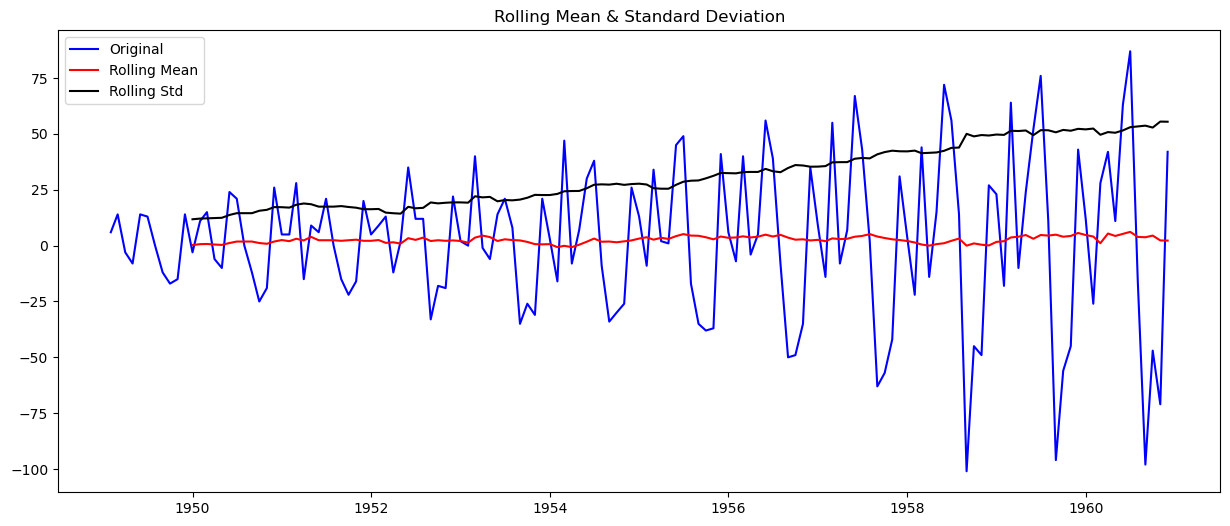

Results of Dickey-Fuller Test:
Test Statistic                                                         -2.829267
p-value                                                                 0.054213
#Lags Used                                                                  12.0
Number of Observations Used                                                130.0
Critical Value (1%)                                                    -3.481682
Critical Value (5%)                                                    -2.884042
Critical Value (10%)                                                    -2.57877
Decision                                                          Non-Stationary
Comment                        Weak evidence against null hypothesis. Fail to...
dtype: object


In [249]:
# SOLUTION
test_stationarity(airpax_data.diff().dropna())

**Réponse**


#### Différenciation saisonnière

<div class="alert alert-block alert-info">
La <b>différenciation saisonnière</b> est une technique utilisée dans l'analyse des séries temporelles pour supprimer les tendances saisonnières des données. La différenciation saisonnière compare les valeurs à la même saison des cycles précédents. Soit $s$ la période saisonnière, alors :
    $$Y_t := X_t - X_{t-s}$$
</div>

La différenciation saisonnière peut être combiné avec une différenciation régulière pour la suppression des tendances et de la saisonnalité dans l'objectif d'obtenir une série stationnaire qui fluctue autour d'une moyenne constante avec une variance constante.


**Q4 :** En considérant que la période saisonnière est 12, appliquer la differenciation saisonnière à la série logarithmique. Ensuite appliquer la différenciation pour enlever la tendance. Faire le test statistique. Commenter.

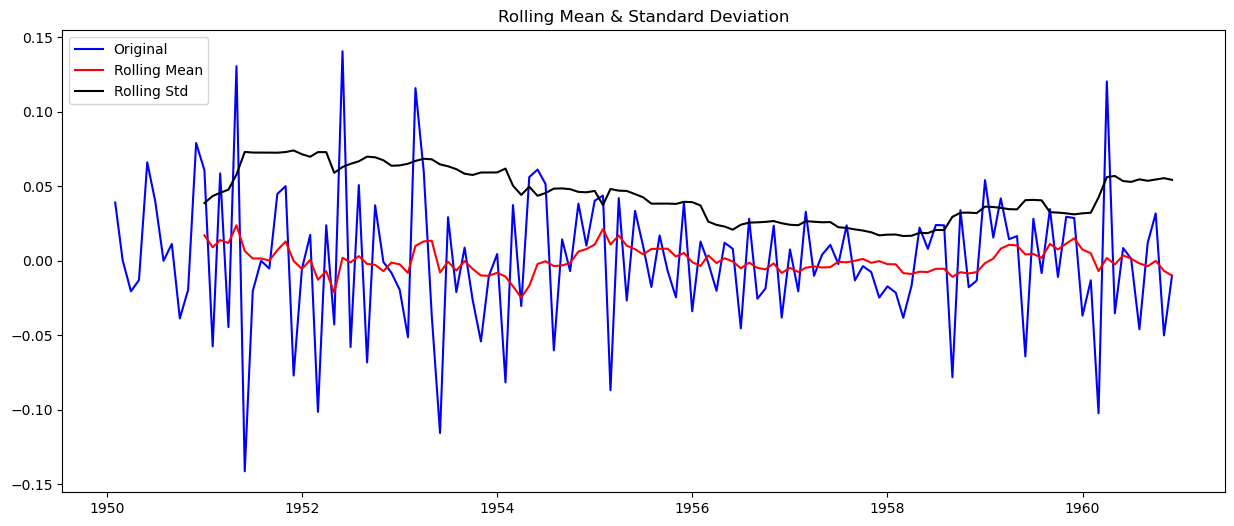

Results of Dickey-Fuller Test:
Test Statistic                                                         -4.443325
p-value                                                                 0.000249
#Lags Used                                                                  12.0
Number of Observations Used                                                118.0
Critical Value (1%)                                                    -3.487022
Critical Value (5%)                                                    -2.886363
Critical Value (10%)                                                   -2.580009
Decision                                                              Stationary
Comment                        Strong evidence against the null hypothesis. R...
dtype: object


In [250]:
# SOLUTION
s=12
yt=airpax_data_log.diff(s).dropna()
zt=yt.diff().dropna()
test_stationarity(zt)

**Réponse**


Lors de la transformation d'une série temporelle pour obtenir la stationnarité, l'ordre des opérations est important.

En général, vous suivriez cette séquence :
1. Transformation logarithmique (si nécessaire pour la stabilisation de la variance)
2. Différenciation saisonnière (pour supprimer la saisonnalité)
3. Différenciation du premier ordre (pour supprimer la tendance restante)

Cette séquence est généralement plus efficace car :
- La différenciation saisonnière permet d'abord d'isoler la composante de tendance
- La différenciation du premier ordre supprime ensuite la tendance restante

Cependant, vous ne devez appliquer que les transformations nécessaires pour obtenir la stationnarité. Après chaque étape, vous pouvez vérifier si une série transformée est stationnaire. Pour certaines séries, vous n'aurez peut-être besoin que d'un seul type de différenciation, et non des deux. Appliquer trop de différenciation peut introduire des modèles artificiels et réduire la précision des prévisions.

#### Vérification de résultat de transformation

La **fonction d'autocorrélation (ACF)** est un outil fondamental de l'analyse des séries temporelles qui mesure la corrélation entre une série temporelle et ses versions décalées (avec un lag).

L'ACF calcule le coefficient de corrélation entre la série originale $Y_t$ et la série décalée de $k$ périodes ($Y_{t-k}$). Elle mesure la dépendance linéaire entre des observations séparées par différents décalages temporels.

<div class="alert alert-block alert-info">

La <b>fonction d'autocorrélation</b> de la série $X_t$ à l'<i>horizon $k$</i> est définie comme 

$$\frac{E\big[(X_i - \mu)(X_{i+k} - \mu )\big]}{\text{Var}(X)} $$

où $\mu$ est la moyenne de $X_t$.

</div>

L'ACF permet de vérifier la stationnarité / non-stationnarité d'une manière suivante : 
* Si la fonction ACF diminue très lentement, la série est probablement non stationnaire.
* Après des transformations appropriées, la fonction ACF devrait rapidement tomber dans la zone de confiance.

Le graphe de la fonction d'autocorrélation est un outil efficace pour déterminer les **périodes** présentes dans une série temporelle. Ainsi, dans le cas de présence de saisonnalité, on peut souvent observer des pics significatifs aux lags saisonniers (e.g. 12, 24, 36 pour les données mensuelles).

Notons aussi que dans le cas de données aléatoire, la fonction ACF va très probablement avoir un seul pic au moment 0.

**Q5 :** Que vaut l'autocorrélation de toute série $X_t$ à l'horizon 0 ? Tracer la fonction d'autocorrélation de deux dernières séries temporelles (série logarithmique et série après la differenciation saisonnière) obtenue à l'aide de la commande [`plot_acf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html) jusqu'à l'horizon (lags) 40. Interpréter.

> 1.

*Note :* Dans un graphique ACF :
* L'axe $y$ indique le coefficient de corrélation (entre -1 et 1)
* L'axe $x$ indique le nombre de décalages (lags)
* Les lignes horizontales en pointillés (ou la zone colorée) représentent les limites de signification statistique (généralement à 95 % de confiance) et ainsi délimite la zone de confiance statistique

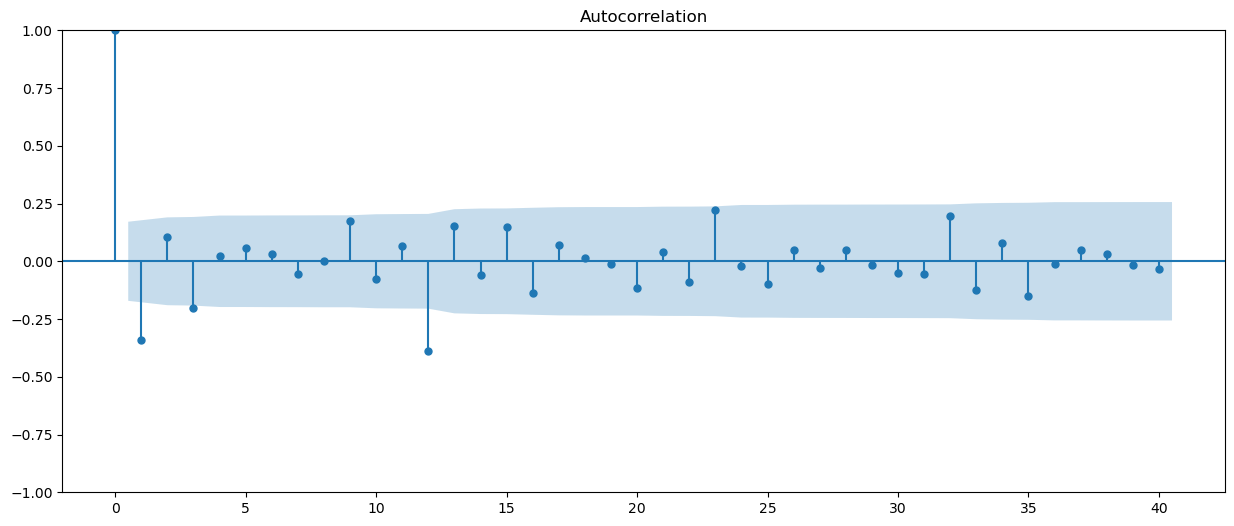

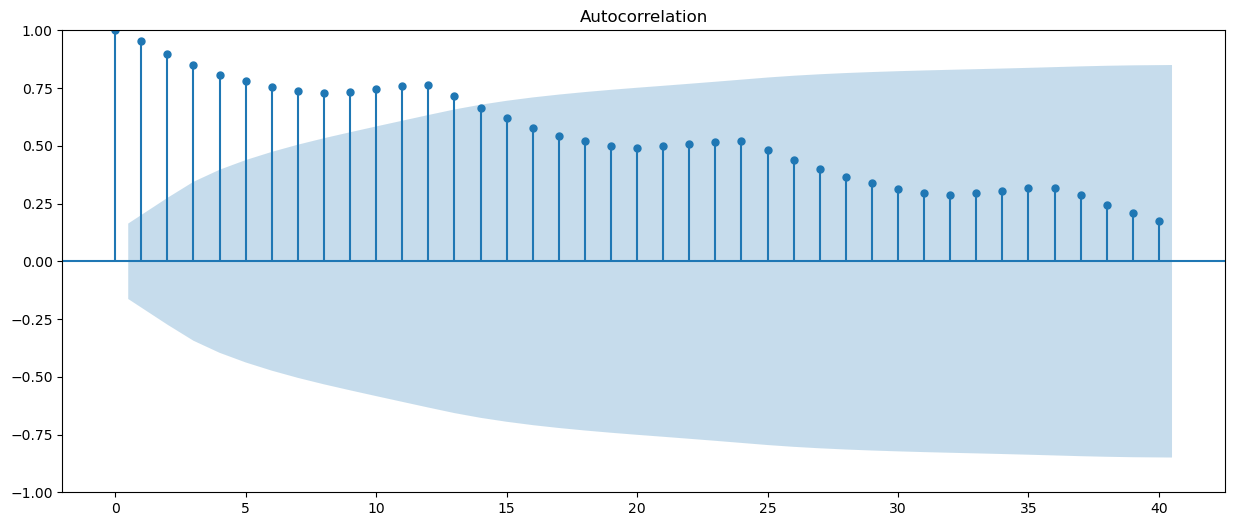

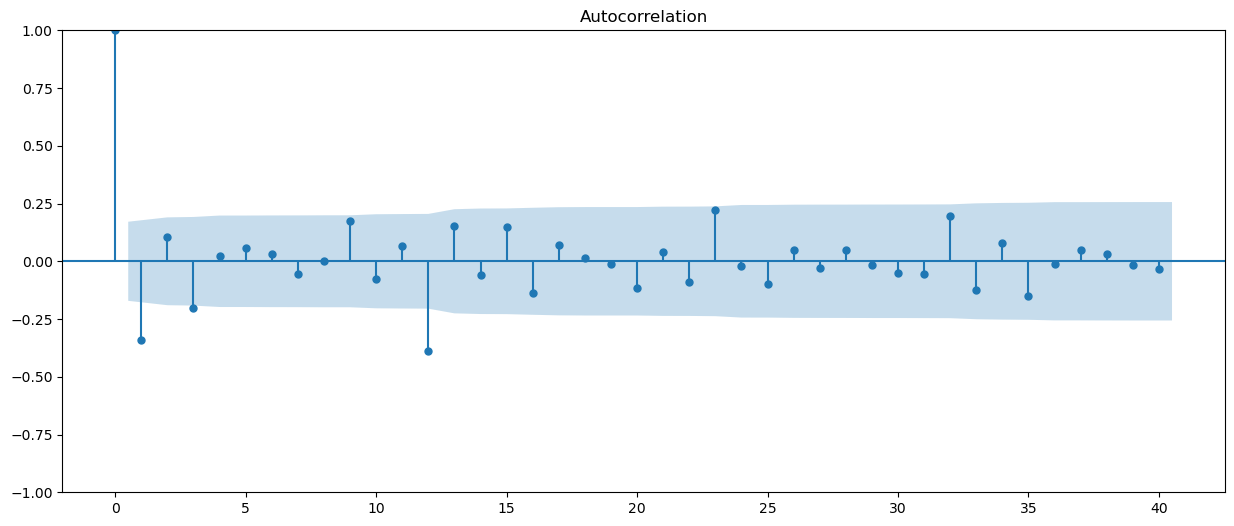

In [251]:
# SOLUTION
import statsmodels
statsmodels.graphics.tsaplots.plot_acf(airpax_data_log, lags=40)
statsmodels.graphics.tsaplots.plot_acf(zt, lags=40)


<div class="alert alert-block alert-info">
    La zone en bleue sur le graphique ci-dessus correspond à la zone de confiance en-dehors de laquelle l'autocorrélation est considérée comme significativement différente de 0.
</div>

**Réponse**
> On remarque bien que dans le cas où l'on a transformé la série en série stationnaire, l'ACF diminue rapidement alors que sur la série où l'on a appliqué le log, ce coefficient diminue très lentement. Cela montre que les opérations effectuées fonctionnent.

## Partie 4. Prévisions avec la méthode de Holt-Winters

La **méthode de Holt-Winters** généralise la méthode par lissage exponentiel décrite ci-dessous dans le cas où la série temporelle à prévoir présente une tendance et une saisonnalité :

<div class="alert alert-block alert-info">
    Soient $\alpha \in [0,1]$. <b>L'estimation par lissage exponentiel simple</b> (en. <i>Simple Exponential Smoothing (SES)</i>) faite au temps T de la série $(x_t)_{t\ge0}$, notée $\widehat{x}_T$, est définie par : 


$$\begin{align*}\widehat{x}_T & := \alpha x_T + (1-\alpha) \widehat{x}_{T-1} \\
& = \alpha x_T + \alpha(1-\alpha) x_{T-1} + \underbrace{(1-\alpha)^2}_{\substack{\text{décroissance exponentielle}\\\text{des coefficients}}} \widehat x_{T-2} \\
& = \alpha \displaystyle \sum_{i=0}^{T-1} (1-\alpha)^i x_{T-i} . \end{align*}$$


</div>

Le lissage exponentiel simple est une méthode de prévision à $t+1$ et est utilisée avec des séries temporelles sans tendance. Le principe de cette méthode de calcul consiste à accorder une plus grande importance aux dernières observations effectuées. Cette méthode est par exemple utilisée en gestion de stocks (en particulier lorsqu'il faut gérer de très nombreuses références).

Le coefficient $\alpha\in[0,1]$ correspond à la *constante de lissage*.

Il est possible d'inclure un horizon dans la fonction de lissage exponentielle.

<div class="alert alert-block alert-info">
    Soient $\alpha \in [0,1]$. <b>L'estimation par lissage exponentiel simple à horizon $h$</b> faite au temps T de la série $(x_t)_{t\ge0}$ à l'horizon h (<i>i.e.</i> au temps T+h), notée $\widehat{x}_T(h)$, est définie par : 


$$\begin{align*}\widehat{x}_T(h) & := \alpha x_T + (1-\alpha) \widehat{x}_{T-h} \\
& = \alpha x_T + \alpha(1-\alpha) x_{T-h} + \underbrace{(1-\alpha)^2}_{\substack{\text{décroissance exponentielle}\\\text{des coefficients}}} \widehat x_{T-2h} \\
& = \alpha \displaystyle \sum_{i=0}^{\lfloor \frac{T}{h}\rfloor-1} (1-\alpha)^i x_{T-i\cdot h} . \end{align*}$$


</div>

**Quand utiliser Holt-Winters :**

- Des patterns saisonniers clairs existent
- Les données historiques montrent des tendances
- Nous cherchons des prévisions à moyen terme 
- Les modèles simples et explicables sont préférables


Le « niveau » désigne la valeur de référence ou la valeur sous-jacente actuelle de la série temporelle après élimination des composantes saisonnières et irrégulières.

**Types de tendance**

Soit $h$ le nombre d"étapes" (pas) dans le futur pour la prévision. 

Nous distongons deux types de tendance dans le contexte de la méthode de Holt-Winters :

* *additive* : la série devrait augmenter ou diminuer d'un montant absolu constant à chaque période, i.e. dans $h$ pas la valeur attendue est donnée par $niveau + (\mbox{trend}\times h)$. Avec une tendance additive, la variation absolue reste constante quel que soit le niveau de la série. *Ewemple : * Si le niveau actuel est de $1000$ et la tendance de $+10$, alors après 3 périodes, nous attendons : $1 000 + (10 × 3) = 1 030$
* *multiplicative* : la série devrait augmenter ou diminuer d'un pourcentage constant à chaque période, i.e. dans $h$ pas la valeur attendue est donnée par $niveau \times (\mbox{trend}^h)$. Avec une tendance multiplicative, la variation absolue augmente à mesure que le niveau de la série augmente, ce qui peut conduire à un comportement exponentiel. *Exemple :* Si le niveau actuel est de $1 000$ et la tendance de $1,02$ (croissance de $2 %$), alors après 3 périodes, nous attendons : $1 000 × (1,02^3) ≈ 1 061$


**Types de saisonnalité**

Soit $h$ le nombre d"étapes" (pas) dans le futur pour la prévision, i.e. nous cherchons $\hat{x}_{n+h}$. Soit $m$ la période (longueur) de la saisonnalité.

Nous distingons deux types de saisonnalité :

* *additive* : $\hat{x}_{n+h} = \mbox{niveau}_n + \underbrace{h\times \mbox{trend}_n}_{\mbox{  tendance} \\ \mbox{sur }h\mbox{ étapes}}+ \mbox{saison}_{n+h_m}$ On l'utilise quand les variations saisonnières sont à peu près constantes en amplitude quel que soit le niveau global de la série
* *multiplicative* : $\hat{x}_{n + h} = (\mbox{niveau}_n + h\times \mbox{trend}_n)\times saison_{n+h-m}$ On l'utilise quand les variations saisonnières augmentent ou diminuent proportionnellement au niveau de la série (comme dans `AirPassengers`)

Notons que la composante de tendance est généralement additive, la composante saisonnière peut être additive ou multiplicative.


**Q5 :**  Créer 2 sous-séries à partir de la série initiale : 80$\%$ de la série servira d'échantillon d'apprentissage (`train`), les 20 derniers pourcents serviront à tester notre lissage (`test`).

In [252]:
# SOLUTION
airpax_data.index = pd.to_datetime(airpax_data.index)
airpax_data = airpax_data.asfreq("MS")  # Month Start
train=airpax_data[:int(airpax_data.count()*0.8)]
test=airpax_data[int(airpax_data.count()*0.8):]

**Q6 :** Créer une fonction `mean_absolute_percentage_error(y_true, y_pred)` qui prend en argument 2 séries `y_pred` et `y_true` et rend la moyenne du rapport des différences des valeurs absolues entre les deux divisé par `y_true`.

In [253]:
# SOLUTION
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    return np.mean(np.abs((y_true - y_pred) / y_true))

**Q7 :** Créer le modèle [`ExponentialSmoothing`](https://www.statsmodels.org/dev/generated/statsmodels.tsa.holtwinters.ExponentialSmoothing.html) avec les bons arguments notamment sur la nature (additive ou multiplicative) du trend et de la saisonnalité. Fit le modèle en précisant le paramètre `optimized=True` pour l'auto-optimization des paramètres, i.e. `.fit(otimized=True)`.

In [254]:
# convert train data to a numpy array before giving it to the model
train_array = train['Airpass'].to_numpy()

In [255]:
# SOLUTION
model = statsmodels.tsa.holtwinters.ExponentialSmoothing(train_array, trend="mul", seasonal="mul", seasonal_periods=12)
res = model.fit(optimized=True)

**Q8 :** Visualiser le sous-échantillon `test` et la prédiction associée sur le même graphique et calculer le `mean_absolute_percentage_error`. Interpréter les paramètres du modèle.

En ce qui concerne l'interprétation des paramètres du modèle :

| paramètre | range de valeur | interprétation | valeur haute (proche de 1) | valeur basse (proche de 0) |
| --------- | --------- |:--------- |:--------- |:--------- |
| `smooting_level` | $0-1$ | Contrôle le poids accordé aux observations récentes par rapport à l'estimation du niveau précédent |<ul> <li>Le modèle s'adapte rapidement aux changements de niveau</li><li>Plus réactif aux données récentes </li><li>Peut réagir de manière excessive aux fluctuations aléatoires </li> </ul>| <ul> <li>Le modèle accorde plus d'importance aux données historiques</li><li>Estimations plus stables, moins sensibles aux changements récents</li><li>Peut être lent à s'adapter aux véritables changements de niveau</li> </ul>|
| `smooting_trend` | $0-1$ | Contrôle le poids accordé au changement de tendance le plus récent par rapport à l'estimation de tendance précédente |<ul> <li> La composante tendance s'adapte rapidement aux changements du taux de croissance </li><li>Plus réactive aux changements récents de tendance</li> </ul> | <ul> <li>Estimations de tendance plus stables </li><li>Réaction plus lente aux changements de modèles de croissance </li><li>Une valeur de 0 signifierait une tendance constante qui ne change jamais</li> </ul> |
| `smooting_seasonal` | $0-1$ | Contrôle le poids accordé à l'observation saisonnière la plus récente par rapport aux estimations saisonnières précédentes | <ul> <li>Les patterns saisonniers s'adaptent rapidement aux changements </li><li>Plus réactifs aux récentes variations saisonnières </li> </ul>|<ul> <li> Des tendances saisonnières plus stables </li><li>Suppose que la saisonnalité est constante d'une année à l'autre </li> </ul>|

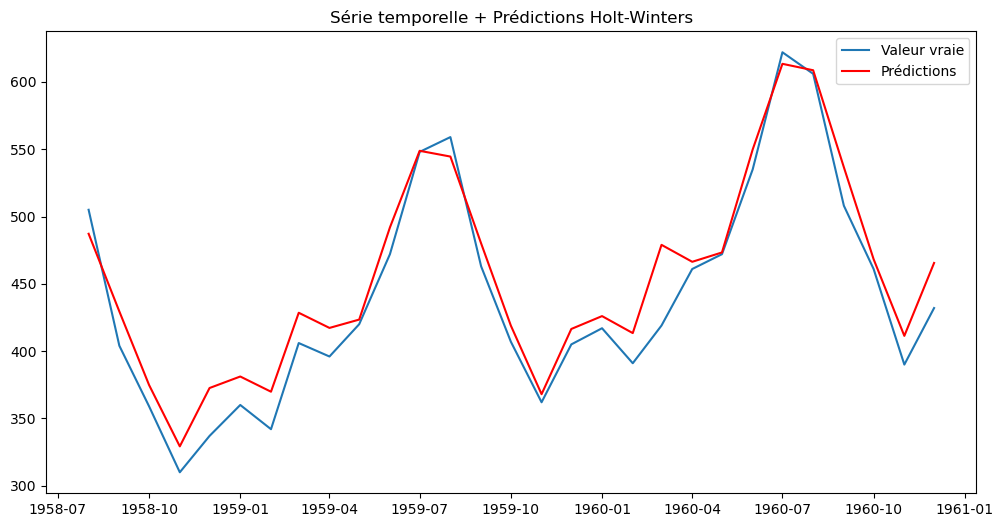

0.9966414755730142

In [259]:
# SOLUTION

pred_array = res.forecast(len(test))
pred = pd.Series(pred_array, index=test.index)
plt.figure(figsize=(12,6))

plt.plot(test, label="Valeur vraie")
plt.plot(pred, label="Prédictions", color="red")

plt.title("Série temporelle + Prédictions Holt-Winters")
plt.legend()
plt.show()

mean_absolute_percentage_error(airpax_data,pred)

In [225]:
# SOLUTION


In [226]:
# SOLUTION
# paramètres


**Réponse**

In [227]:
# SOLUTION 
# erreur 

**Réponse**


In [228]:
# SOLUTION
# visualisation


**Q9 :** Quelle influence ont sur les prévisions les choix additif/multiplicatif ainsi que la période ? Faites des essais et conclure.

In [229]:
# SOLUTION


**Réponse**